In [2]:
import os
import random
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse
from torch_geometric.nn import global_mean_pool, global_max_pool, Set2Set
from torch_geometric.nn import NNConv, CGConv, GCNConv, GATConv, GATv2Conv

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN
from pymatgen.util import coord as puc
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifWriter
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize.plot import plot_atoms
from pymatgen.analysis.graphs import StructureGraph


from graphy_cvae import get_full_defective, get_nodes, get_edges, get_features
from graphy_cvae import get_mask, get_globals, get_cloud, get_graphs, get_target_tensor

/home/amutua/inverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Prep

In [3]:
# The whole dataset
comb_df = pd.read_csv(f"Final_Dataset/combined/combined_data.csv")
# sample_df = comb_df.sample(10, random_state=42)

# Sample row
an_index = random.randint(0, len(comb_df)-1)
a_row = comb_df.iloc[an_index]
# sample_row = sample_df.iloc[0]

# Get required attributes from sample row
a_dataset_material = a_row["dataset_material"]
a_material = a_dataset_material.split("_")[1]
an_id = a_row["_id"]
a_bgv = a_row["band_gap_value"]

# Get defective structure
a_defective_file_path = f"original_dataset/{a_dataset_material}/cifs/{an_id}.cif"
a_defective_structure = Structure.from_file(a_defective_file_path)

# Get reference structure
a_ref_file_path = f"Final_Dataset/ref_cifs/{a_dataset_material}.cif"
a_reference_structure = Structure.from_file(a_ref_file_path)

a_full_defective_structure  = get_full_defective(a_reference_structure, a_defective_structure)
a_full_defective_nodes      = get_nodes(a_full_defective_structure)
a_full_defective_edges      = get_edges(a_full_defective_structure)
a_full_defective_E_features = get_features(a_full_defective_edges, a_full_defective_structure)
a_full_defective_mask       = get_mask(a_reference_structure)
a_full_defective_u          = get_globals(a_material, a_bgv)
a_full_defective_target     = get_target_tensor(a_full_defective_structure)

/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 47 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


## Implimentation on the whole dataset

In [4]:
# ================================
# WHOLE DATA
# ================================
'''
train_set, val_set = train_test_split(comb_df, test_size=0.3, random_state=42, stratify=comb_df["strata"])

train_graphs = get_graphs(train_set)
val_graphs = get_graphs(val_set)

torch.save(train_graphs, "Final_Dataset/cvae models/cvae_train_graphs.pt")
torch.save(val_graphs, "Final_Dataset/cvae models/cvae_val_graphs.pt")
'''
# ===============================
# HIGH DATASET ONLY
# ===============================
'''
sample_df = comb_df[(comb_df["dataset_material"] != "low_MoS2") & (comb_df["dataset_material"] != "low_WSe2")]

print(len(sample_df))

sample_train, sample_val = train_test_split(sample_df, test_size=0.25, random_state=42, stratify=sample_df["strata"])

sample_train_graphs = get_graphs(sample_train)
sample_val_graphs = get_graphs(sample_val)

# torch.save(sample_train_graphs, f"Final_Dataset/cvae models/high_cvae_train_graphs.pt")
# torch.save(sample_val_graphs, f"Final_Dataset/cvae models/high_cvae_val_graphs.pt")
'''

# =============================
# HIGH MoS2 & HIGH WSe2
# =============================

'''
high_mos2_df = comb_df[comb_df["dataset_material"] == "high_MoS2"]


sample_train, sample_val = train_test_split(high_mos2_df, test_size=0.25, random_state=42, stratify=high_mos2_df["strata"])

sample_train_graphs = get_graphs(sample_train)
sample_val_graphs = get_graphs(sample_val)

# torch.save(sample_train_graphs, "Final_Dataset/cvae models/high_cvae_train_graphs.pt")
# torch.save(sample_val_graphs, "Final_Dataset/cvae models/high_cvae_val_graphs.pt")
'''

'\nhigh_mos2_df = comb_df[comb_df["dataset_material"] == "high_MoS2"]\n\n\nsample_train, sample_val = train_test_split(high_mos2_df, test_size=0.25, random_state=42, stratify=high_mos2_df["strata"])\n\nsample_train_graphs = get_graphs(sample_train)\nsample_val_graphs = get_graphs(sample_val)\n\n# torch.save(sample_train_graphs, "Final_Dataset/cvae models/high_cvae_train_graphs.pt")\n# torch.save(sample_val_graphs, "Final_Dataset/cvae models/high_cvae_val_graphs.pt")\n'

In [5]:
def get_pristine_edges(structure):
    # 2. Generate a StructureGraph using a neighbor strategy (e.g., CrystalNN)
    mdnn = MinimumDistanceNN()
    the_graph = StructureGraph.with_local_env_strategy(structure, mdnn)

    # 3. Extract edge indices (COO format: [source_indices, target_indices])
    edge_indices = []
    for u, v, _ in the_graph.graph.edges(data=True):
        edge_indices.append([u, v])
        edge_indices.append([v, u])

    edge_indices = np.array(edge_indices).T  # Shape: (2, num_edges)
    return edge_indices

In [6]:
def get_site_features(structure):
    # all_coords = structure.cart_coords  # .get_fractional_coords(defective_struct.cart_coords)
    # print(all_coords)
    all_features= []
    for a_site in structure.sites:
        site = a_site.specie

        coords = a_site.coords
        p_Z = site.Z
        p_X = site.X
        p_ar = site.atomic_radius
        p_row = site.row
        p_group = site.group
        p_ea = site.electron_affinity
        p_cos = max(site.common_oxidation_states)

        site_features = np.concatenate((coords, np.array([p_Z, p_X, p_ar, p_row, p_group, p_ea, p_cos])))

        all_features.append(site_features)

    return all_features

BN_features = get_site_features(Structure.from_file("Final_Dataset/ref_cifs/high_BN.cif"))

/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [7]:
def get_pristine_mask(structure):
    masking_dict = {
        "Ga":"In", "Se":"S", "In":"Ga", 
        "B":"C", "N":"C", "P":"N", 
        "W":"Mo", "Mo":"W", "S":"Se"
    }

    the_masks = []

    for site in structure.sites:
        specie_now = site.specie.symbol

        # Normal site 
        norm = site.specie.Z

        # Vacancy site
        vac = 0

        # Sub site
        allowed_sub = masking_dict[specie_now]
        sub = Element(allowed_sub).Z

        # The row mask
        row_mask = [norm, vac, sub]
        
        the_masks.append(row_mask)

    
    return the_masks

GaSe_mask = get_pristine_mask(Structure.from_file("Final_Dataset/ref_cifs/high_GaSe.cif"))


In [8]:
# Load graphs
# full_train_graphs = torch.load("Final_Dataset/cvae graphs/cvae_train_graphs.pt", weights_only=False)
# full_val_graphs = torch.load("Final_Dataset/cvae graphs/cvae_val_graphs.pt", weights_only=False)

high_train_graphs = torch.load("Final_Dataset/cvae graphs/high_cvae_train_graphs.pt", weights_only=False)
high_val_graphs = torch.load("Final_Dataset/cvae graphs/high_cvae_val_graphs.pt", weights_only=False)

# subset_indices = torch.randperm(2000)[:600]
# train_sub_dataset = torch.utils.data.Subset(high_train_graphs, subset_indices)

def add_bond_batch(graph):
    for data in graph:
        bond_batch = torch.zeros((1, data.edge_index.shape[1]))
        data.bond_batch = bond_batch.squeeze(0).to(dtype=torch.long)

    return graph

def add_pristine_edges(graph):
    materials = ["GaSe", "InSe", "BN", "P", "WSe2", "MoS2"]

    all_pristine_edges = []
    for material in materials:
        structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_{material}.cif")

        edge_indices = get_pristine_edges(structure)
        
        all_pristine_edges.append(edge_indices)

    for data in graph:
        # Get index with 1 in the first 6 global attributes
        one_hot = data.u[0, :6]
        the_index = torch.argmax(one_hot)
        data.pristine_edges = torch.tensor(all_pristine_edges[the_index], dtype=torch.long)

    return graph

def add_pristine_site_features(graph):
    materials = ["GaSe", "InSe", "BN", "P", "WSe2", "MoS2"]

    all_pristine_features = []
    for material in materials:
        structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_{material}.cif")

        p_features = get_site_features(structure)
        
        all_pristine_features.append(p_features)

    for data in graph:
        # Get index with 1 in the first 6 global attributes
        one_hot = data.u[0, :6]
        the_index = torch.argmax(one_hot)
        data.pristine_features = torch.tensor(all_pristine_features[the_index], dtype=torch.float)

    return graph

def add_new_mask(graph):
    materials = ["GaSe", "InSe", "BN", "P", "WSe2", "MoS2"]

    all_masks = []
    for material in materials:
        structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_{material}.cif")

        new_mask = get_pristine_mask(structure)
        
        all_masks.append(new_mask)

    for data in graph:
        # Get index with 1 in the first 6 global attributes
        one_hot = data.u[0, :6]
        the_index = torch.argmax(one_hot)
        data.pristine_mask = torch.tensor(all_masks[the_index], dtype=torch.long)

    return graph

def add_num_defects(graph):
    for data in graph:
        num_defects = data.y[:, :1].squeeze(-1).to(dtype=torch.float).sum()
        data.num_defects = num_defects.reshape((1,1))
    return graph
        

new_high_train_graphs = add_bond_batch(high_train_graphs)
new_high_val_graphs = add_bond_batch(high_val_graphs)

new_high_train_graphs = add_pristine_edges(new_high_train_graphs)
new_high_val_graphs = add_pristine_edges(new_high_val_graphs)

new_high_train_graphs = add_pristine_site_features(new_high_train_graphs)
new_high_val_graphs = add_pristine_site_features(new_high_val_graphs)


new_high_train_graphs = add_new_mask(new_high_train_graphs)
new_high_val_graphs = add_new_mask(new_high_val_graphs)

new_high_train_graphs = add_num_defects(new_high_train_graphs)
new_high_val_graphs = add_num_defects(new_high_val_graphs)

class FeatureScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, graphs, attr):
        all_vals = torch.cat([getattr(g, attr) for g in graphs], dim=0)
        self.mean = all_vals.mean(dim=0, keepdim=True)
        self.std = all_vals.std(dim=0, keepdim=True) + 1e-8
        return self

    def transform(self, graphs, attr):
        for g in graphs:
            setattr(g, attr, (getattr(g, attr) - self.mean) / self.std)
        return graphs

    
x_scaler = FeatureScaler().fit(new_high_train_graphs, "x")
edge_scaler = FeatureScaler().fit(new_high_train_graphs, "edge_attr")
u_scaler = FeatureScaler().fit(new_high_train_graphs, "u")

new_graphs = []

for split in [new_high_train_graphs, new_high_val_graphs]:
    split = x_scaler.transform(split, "x")
    split = edge_scaler.transform(split, "edge_attr")
    split = u_scaler.transform(split, "u")
    new_graphs.append(split)

new_high_train_graphs = new_graphs[0]
new_high_val_graphs = new_graphs[1]
# test_graphs = new_graphs[2]

# Create data loaders
# full_train_loader = DataLoader(full_train_graphs, batch_size=1, shuffle=True) 
# full_val_loader   = DataLoader(full_val_graphs, batch_size=1, shuffle=False)

high_train_loader = DataLoader(new_high_train_graphs, batch_size=1, shuffle=True) 
high_val_loader   = DataLoader(new_high_val_graphs, batch_size=1, shuffle=False)
# high_train_loader = DataLoader(train_sub_dataset, batch_size=1, shuffle=True)
# high_val_loader   = DataLoader(high_val_graphs, batch_size=1, shuffle=False)


# Visualize the shape of the data
'''for batch in full_train_loader:
    print(f"Full data sample: {batch}")
    break'''

for batch in high_train_loader:
    print(f"High data sample: {batch}")
    break

/tmp/ipykernel_1096323/3557309929.py:4: FutureWarning: with_local_env_strategy is deprecated, and will be removed on 2025-03-20
Use from_local_env_strategy in pymatgen.analysis.graphs instead.
Deprecated on 2024-03-29.
  the_graph = StructureGraph.with_local_env_strategy(structure, mdnn)
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/tmp/ipykernel_1096323/621891441.py:52: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data.pristine_features = torch.tensor(all_pristine_features[the_index], dtype=torch.float)


High data sample: DataBatch(x=[144, 19], edge_index=[2, 384], edge_attr=[384, 7], y=[144, 120], u=[1, 7], mask=[119], bond_batch=[384], pristine_edges=[2, 504], pristine_features=[144, 10], pristine_mask=[144, 3], num_defects=[1, 1], batch=[144], ptr=[2])


In [9]:
# sample_0 = full_train_loader.dataset[0]
sample_0 = high_train_loader.dataset[0]

NODE_DIM   = sample_0.x.shape[1] 
EDGE_DIM   = sample_0.edge_attr.shape[1] 
U_DIM      = sample_0.u.shape[1] 
MASK_DIM   = sample_0.mask.shape[0]
TARGET_DIM = sample_0.y.shape[1]

HIDDEN_DIM = 256
LATENT_DIM = 32

print(f"Node dim: {NODE_DIM}\nEdge dim: {EDGE_DIM}\nU dim: {U_DIM}\nMask Dim: {MASK_DIM}\nTarget Dim: {TARGET_DIM}")

Node dim: 19
Edge dim: 7
U dim: 7
Mask Dim: 119
Target Dim: 120


In [10]:
for sample_0 in high_train_loader:
    # print(sample_0)
    sample_y = sample_0.y

    sample_sites = sample_y[:, :1]
    sample_sites = sample_sites.squeeze(-1).to(dtype=torch.long)

    sample_species = torch.argmax(sample_y[:, 1:], dim=1)

    print(sample_sites.shape)
    print(sample_sites)
    print(sample_species.shape)
    print(sample_species)

    
    # print(torch.argmax(sample_species, dim=1))

    # sample_sites = sample_sites.reshape(1, sample_sites.shape[0])
    # print(sample_sites.to(dtype=torch.long))
    # sample_species = sample_species.squeeze(1)

    # print(sample_sites.shape)
    # print(sample_species.shape)


    break

torch.Size([192])
tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
torch.Size([192])
tensor([ 0, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 74,
        42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42,  0,
        42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 74, 74, 42, 42, 42, 42,
        42, 42, 42, 42,  0, 42, 42, 42, 42, 74, 16, 16, 16, 16, 16, 16, 16, 16,
   

## The model architecture

### Why the Variational Autoencoder?

This functions as a **true generative model**. Remember the goal is to be generate new materials, something the normal autoencoders fail at. 

The **conditional** part of the model is the fact that we are trying to **generate new defective structures** with a **desired band gap values**. 

To achieve this we concatenate the band gap as the label in the input data that will be passed in the encoder,  and with the latent vector that will be passed to the decoder. 

This ensures the model learns to generate structures specific to the band gap.

## Encoder

The encoder takes the defective structure and **learns the key features** of the structure and produces two vectors:

- Mean (μ): A central value representing the data.
- Standard Deviation (σ): It is a measure of how much the values can vary.

Why?
This is because the main goal is to produce a **latent representation** of the structure. 



In [11]:
from torch_geometric.utils import scatter

class ShiftedSoftplus(nn.Module):
    def __init__(self):
        super().__init__()
        self.sp = nn.Softplus()
        self.shift = nn.Parameter(torch.log(torch.tensor([2.])), requires_grad=False)

    def forward(self, x):
        return self.sp(x) - self.shift

In [12]:
# Encoder that looks like MEGNet

class MEGNetBlock(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()

        self.phi_e = nn.Sequential(
            nn.Linear(4 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.phi_v = nn.Sequential(
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.phi_u = nn.Sequential(
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

    def forward(self, x, edge_index, edge_attr, u, batch, bond_batch):
        row, col = edge_index

        u_per_edge = u[bond_batch]
        edge_attr = self.phi_e(torch.cat([x[row], x[col], edge_attr, u_per_edge], dim=1))

        agg_edges = scatter(edge_attr, row, dim=0, dim_size=x.size(0), reduce='mean')
        u_per_node = u[batch]
        x = self.phi_v(torch.cat([agg_edges, x, u_per_node], dim=1))

        edge_pooled = global_mean_pool(edge_attr, bond_batch)
        node_pooled = global_mean_pool(x, batch)

        u = self.phi_u(torch.cat([edge_pooled, node_pooled, u], dim=1))

        return x, edge_attr, u


class EncoderPart(nn.Module):
    def __init__(self, node_dim, edge_dim, u_dim, embed_dim, num_blocks=3):
        super().__init__()
        self.nodes_mlp = nn.Sequential(
            nn.Linear(node_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )
        self.edge_attr_mlp = nn.Sequential(
            nn.Linear(edge_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )
        self.u_mlp = nn.Sequential(
            nn.Linear(u_dim + 1, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.blocks = nn.ModuleList([MEGNetBlock(embed_dim) for _ in range(num_blocks)])

        self.set2set_x = Set2Set(embed_dim, processing_steps=3)
        self.set2set_edge_attr = Set2Set(embed_dim, processing_steps=3)

        self.readout = nn.Sequential(
            nn.Linear(5 * embed_dim, 4 * embed_dim), ShiftedSoftplus(),
            nn.Linear(4 * embed_dim, 3 * embed_dim), ShiftedSoftplus(),
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
        )

        self.mu_layer  = nn.Linear(2 * embed_dim, embed_dim)
        self.var_layer = nn.Linear(2 * embed_dim, embed_dim)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, bond_batch, num_defects = (
            data.x, data.edge_index, data.edge_attr, data.batch, data.u, data.bond_batch, data.num_defects
        )

        x = self.nodes_mlp(x)
        edge_attr = self.edge_attr_mlp(edge_attr)
        u = self.u_mlp(torch.cat([u, num_defects], dim=1))

        for block in self.blocks:
            x_new, edge_attr_new, u_new = block(x, edge_index, edge_attr, u, batch, bond_batch)
            # Residual connections: lets each block refine rather than overwrite,
            # and keeps gradients healthy through 3 stacked blocks
            x = x + x_new
            edge_attr = edge_attr + edge_attr_new
            u = u + u_new

        x_pool = self.set2set_x(x, batch)
        edge_pool = self.set2set_edge_attr(edge_attr, bond_batch)

        out = torch.cat([x_pool, edge_pool, u], dim=1)
        out = self.readout(out)
        
        mu  = self.mu_layer(out) 
        var = self.var_layer(out)
            
        return mu, var

for the_sample in high_train_loader:
# for the_sample in full_train_loader:

    MAX = the_sample.x.shape[0]

    # Test encoder
    test_encoder = EncoderPart(NODE_DIM, EDGE_DIM, U_DIM, embed_dim=32, num_blocks=3)
    out_mu, out_var = test_encoder(the_sample)
    print("TESTING ENCODER\n")
    
    print("Mu shape:", out_mu.shape)
    print("Mu sample:\n", out_mu)
    
    print("\nLog var shape:", out_var.shape)
    print("Log var Sample:\n", out_var)

    break

TESTING ENCODER

Mu shape: torch.Size([1, 32])
Mu sample:
 tensor([[ 0.0585,  0.0283, -0.0867,  0.0094,  0.0098,  0.0193,  0.0559,  0.0379,
         -0.1147, -0.0348, -0.0034,  0.0767, -0.0161, -0.1204, -0.0763, -0.0108,
         -0.1154, -0.0075,  0.0737,  0.0915,  0.0870,  0.1247, -0.0198, -0.0556,
         -0.0449, -0.0121,  0.0370, -0.0849,  0.1485,  0.0837, -0.0260, -0.0250]],
       grad_fn=<AddmmBackward0>)

Log var shape: torch.Size([1, 32])
Log var Sample:
 tensor([[ 0.0038,  0.0886,  0.0687,  0.0955, -0.0852, -0.0793,  0.0983, -0.0327,
          0.0106,  0.1445,  0.0872, -0.0904, -0.0717, -0.0624, -0.0891,  0.0113,
          0.1109,  0.0310,  0.0578, -0.0171,  0.0658,  0.1125, -0.0853, -0.1025,
         -0.0708,  0.0576,  0.0180, -0.0844,  0.0529, -0.0320, -0.0395,  0.0487]],
       grad_fn=<AddmmBackward0>)


In [12]:
# Encoder
class CVAE_Encoder(nn.Module):
    def __init__(self, node_dim, edge_dim, u_dim, hidden_dim, latent_dim):
        super().__init__()

        # self.edge_nn = nn.Sequential(nn.Linear(edge_dim, 64),nn.ReLU(),nn.Linear(64, node_dim * hidden_dim))
        # self.conv0 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        self.dropout = nn.Dropout(p=0.1)

        # ==============================

        # Learn crystal graph properties
        self.normalize = nn.BatchNorm1d(128)
        self.conv0 = GATv2Conv(node_dim, 128, edge_dim=edge_dim)
        # self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(128, 128)
        self.conv3 = GCNConv(128,64)

        # Max pool and Mean pool then combine to get 64 * 2

        self.after_conv = nn.Linear(64 * 2, 64)

        # =============================

        # Learn global properties
        self.global_embed = nn.Linear(1, 64) # (u_dim, 64)

        # =============================

        # Site embedding
        self.learn_site = nn.Embedding(192,16)

        # Specie embedding
        self.learn_specie = nn.Embedding(192, 16)

        # Padding 
        self.pad = nn.Parameter(torch.randn(32))

        # =============================

        self.seq_combine = nn.Sequential(
            nn.Linear(128 + 64, 64*3), nn.ReLU(),
            nn.Linear(64*3, 64*2), nn.ReLU(),
            nn.Linear(64*2, 64), nn.ReLU()
        )
        
        self.mu_layer  = nn.Linear(64, latent_dim)
        self.var_layer = nn.Linear(64, latent_dim)


    def forward(self, data):
        start_x, edge_index, edge_attr, batch, u, y= (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u, 
            data.y
        )

        # ==================
        x = F.relu(self.normalize(self.conv0(start_x, edge_index, edge_attr)))
        # x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.normalize(self.conv2(x, edge_index)))
        x = F.relu(self.conv3(x, edge_index))

        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x,batch)

        x = torch.cat([x_max, x_mean], dim=1)

        x = F.relu(self.after_conv(x))  # x.shape = [1,64]

        # ==================

        u = self.global_embed(u[..., 6].unsqueeze(0))

        x = torch.cat([x,u], dim=1) # x.shape = [1,128]

        # ==================
        # the_sites = torch.arange(y.shape[0], device=y.device)
        the_sites = y[:, :1].flatten().to(dtype=torch.int)
        site_embed = self.learn_site(the_sites)  # [y.shape[0], 16]

        the_species = torch.argmax(y[:, 1:], dim=1)
        specie_embed = self.learn_specie(the_species) # [y.shape[0], 16]

        ss_embed = torch.cat([site_embed, specie_embed], dim=-1) # [y.shape[0], 32]

        '''if ss_embed.shape[0] < 192:
            # Pad the remaining 
            needed = 192-ss_embed.shape[0] # Number of rows to add
            to_add = self.pad.unsqueeze(0).repeat(needed, 1) # rows to add

            ss_embed = torch.cat([ss_embed, to_add], dim=0) # [192,32]'''


        # new_embed = ss_embed.flatten().unsqueeze(0) # [1,(192*32)] = [1,6144]
        mean_embed = global_mean_pool(ss_embed, batch)
        max_embed = global_max_pool(ss_embed, batch)

        new_embed = torch.cat([mean_embed, max_embed], dim=-1) # [1,64]

        x = torch.cat([x,new_embed], dim=-1) # [1, 192]

        # ==================

        x = self.seq_combine(x)
        x = self.dropout(x)

        # x = x.mean(dim=0, keepdim=True)

        mu  = self.mu_layer(x) 
        var = self.var_layer(x)
        
        return mu, var

for the_sample in high_train_loader:
# for the_sample in full_train_loader:

    MAX = the_sample.x.shape[0]

    # Test encoder
    test_encoder = CVAE_Encoder(NODE_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    out_mu, out_var = test_encoder(the_sample)
    print("TESTING ENCODER\n")
    
    print("Mu shape:", out_mu.shape)
    print("Mu sample:\n", out_mu)
    
    print("\nLog var shape:", out_var.shape)
    print("Log var Sample:\n", out_var)

    break

TESTING ENCODER

Mu shape: torch.Size([1, 32])
Mu sample:
 tensor([[ 0.0681, -0.1702, -0.0387, -0.0472,  0.0266, -0.0360,  0.0176, -0.1014,
          0.0568, -0.0734,  0.1170,  0.0269, -0.0667,  0.0137, -0.1372,  0.0361,
         -0.1372,  0.0262,  0.0191, -0.1102,  0.0571, -0.0091,  0.0745,  0.0636,
         -0.0722,  0.0392,  0.0103, -0.0416, -0.0771, -0.0117,  0.0106, -0.1207]],
       grad_fn=<AddmmBackward0>)

Log var shape: torch.Size([1, 32])
Log var Sample:
 tensor([[-0.1189,  0.0292, -0.1011, -0.1309, -0.0855, -0.0243,  0.0438, -0.0267,
          0.1751,  0.0896,  0.1065, -0.0644,  0.1563, -0.0654, -0.0154,  0.0332,
          0.1121,  0.0400,  0.0964,  0.1474,  0.0702,  0.1194,  0.0113,  0.0303,
         -0.0457,  0.1007,  0.0827, -0.1471, -0.0021,  0.0290,  0.0294, -0.0699]],
       grad_fn=<AddmmBackward0>)


## Decoder

The decoder reconstructs/generates the data based on the latent space created

In [13]:
def clean_decoder_target(sample_y):
    sample_sites = sample_y[:, :1]
    sample_sites = sample_sites.squeeze(-1).to(dtype=torch.long)

    num_defects = sample_sites.sum()
    
    sample_species = torch.argmax(sample_y[:, 1:], dim=1)

    print("DECODER TARGET")
    print(num_defects)
    print(sample_sites)
    print(sample_species)

def clean_decoder_output(out_decoder):
    out_sites = out_decoder[:, 0]
    out_species = out_decoder[:, 1]

    num_defects = out_sites.sum()

    print("DECODER OUTPUT")
    print(num_defects)
    print(out_sites)
    print(out_species)

    
def logits_to_actuals(num_defects, the_sites, defect_type, pristine_mask):
    # num_defects = self.out_num_defects_mlp(for_u)
    num_defects = 2.0 + 25.0 * torch.sigmoid(num_defects)
    num_defects = num_defects.int().item()

    # =============

    # Sites with the defects

    # introduce topk
    the_sites = the_sites.squeeze(1)

    v, indices = torch.topk(the_sites, k=num_defects)

    # use the indices to make new sam
    true_sites = torch.zeros_like(the_sites)

    true_sites[indices] = 1
    # true_sites = true_sites.unsqueeze(-1)

    # =============
    
    # Type of defect at the site with defects 

    # Find defect type of defective sites only
    true_defect_types = torch.zeros((defect_type.size(0)), dtype=torch.long)

    types = torch.argmax(defect_type[indices], dim=1)  + 1

    true_defect_types[indices] = types

    # Clean representation of species
    out_types = pristine_mask[torch.arange(len(true_defect_types)), true_defect_types]

    # =========================
    # Combine everything 

    fine_recon = torch.stack((true_sites, out_types), dim=1)
    
    return fine_recon

In [15]:
# Decoder
class MegnetDecoderBlock(nn.Module):
    def __init__(self, latent_dim, mask_dim):
        super().__init__()

        # Number of defects
        self.u_mlp = nn.Sequential(
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus()
        )

        # Sites with defects
        self.sites_mlp = nn.Sequential(
            nn.Linear(latent_dim*4, latent_dim*3), ShiftedSoftplus(),
            nn.Linear(latent_dim*3, latent_dim*2), ShiftedSoftplus(), 
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(), 
        )

        # # Species
        # self.species_mlp = nn.Sequential(
        #     nn.Linear(latent_dim*3 + mask_dim*2, latent_dim*2 + mask_dim*2), ShiftedSoftplus(),
        #     nn.Linear(latent_dim*2 + mask_dim*2, latent_dim   + mask_dim*2), ShiftedSoftplus(),
        #     nn.Linear(latent_dim   + mask_dim*2, latent_dim   + mask_dim), ShiftedSoftplus(), 
        #     nn.Linear(latent_dim   + mask_dim  , mask_dim), ShiftedSoftplus(), 

        # )

        

    def forward(self, z, u, for_sites, pristine_edges):

        # =======================
        for_u = torch.cat([z,u], dim=1)
        out_u = self.u_mlp(for_u)

        # =======================
        row, col = pristine_edges

        num_edges = row.size(0)

        z_replicated = z.repeat(num_edges, 1)
        out_u_replicated = out_u.repeat(num_edges, 1)

        comb_for_sites = torch.cat(
            [for_sites[row], for_sites[col], z_replicated, out_u_replicated], 
            dim=1
        )

        out_sites = self.sites_mlp(comb_for_sites)

        # ========================

        # for_species = out_sites @ for_species.T

        # comb_for_species = torch.cat(
        #     [for_species[row], for_species[col], out_sites,  z_replicated, out_u_replicated], 
        #     dim=1
        # )
        
        # out_species = self.species_mlp(comb_for_species)

        # out_species = scatter(out_species, row, dim=0, reduce='mean')
        out_sites = scatter(out_sites, row, dim=0, reduce='mean')

        return out_u, out_sites # , out_species


class DecoderPart(nn.Module):
    def __init__(self, latent_dim, mask_dim, max_sites=192, bgv_dim=1, num_blocks=3):
        super().__init__()

        self.mask_dim = mask_dim
        self.latent_dim = latent_dim

        # ========================
        # GLOBAL ATTRIBUTES

        # Materials: [1, 6] --> [6,32]
        self.embed_materials = nn.Embedding(6, latent_dim)

        # Band Gap Value [1,1] --> [1,32]
        self.bgv_mlp = nn.Sequential(
            nn.Linear(bgv_dim, latent_dim*2), ShiftedSoftplus(),
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus()
        )

        # Materials and bgv combined : [1,32] + [6,32] --> [7,32] --> [1, 7*32] --> [1,32]
        self.u_mlp = nn.Sequential(
            nn.Linear(latent_dim*7, latent_dim*5), ShiftedSoftplus(),
            nn.Linear(latent_dim*5, latent_dim*3), ShiftedSoftplus(),
            nn.Linear(latent_dim*3, latent_dim), ShiftedSoftplus(),
        )
        # ========================
        # PREPARE FOR SITES AND FOR SPECIES

        self.for_sites_mlp = nn.Sequential(
            nn.Linear(10, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
        )

        self.for_species_embedding = nn.Embedding(mask_dim, latent_dim)

        # ============================
        # MESSAGE PASSING THROUGH MEGNET BLOCK
        self.blocks = nn.ModuleList(
            [MegnetDecoderBlock(latent_dim, mask_dim) for _ in range(num_blocks)]
        )

        # =========================
        # CREATE OUTPUTS

        # DEFECT NUMBER
        self.out_num_defects_mlp = nn.Sequential(
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 1)
        )

        # SITES
        self.out_sites_mlp = nn.Sequential(
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 1), nn.Sigmoid()
        )

        # SPECIES
        self.out_species_mlp = nn.Sequential(
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 3)
        )


    def forward(
            self, z, condition_vector, out_sites, 
            pristine_mask, pristine_edges, pristine_features
        ):   
        # ======================
        # one_hot_materials = condition_vector[0, :6].squeeze(-1).to(dtype=torch.long)
        bgv = condition_vector[0,6:].unsqueeze(-1)


        # for_materials = self.embed_materials(one_hot_materials) #[6,32]
        for_bgv= self.bgv_mlp(bgv) #[1,32]

        # for_u = torch.cat([for_materials, for_bgv], dim= 0) # [7,32]
        # for_u = for_u.flatten().unsqueeze(0) # [1, 224]
        
        # for_u = self.u_mlp(u) # [1,32]   <----------
        for_u = for_bgv


        # SITES
        for_sites = self.for_sites_mlp(pristine_features) # [192,10] -> [192,32] <--------------
        
        # # SPECIES
        # species_indices = torch.arange(self.mask_dim, device=z.device) # [0,1,2,3,...,119]
        # for_species = self.for_species_embedding(species_indices) # [119,32] <-------------

        # =================
        # Perform message passing

        # all_species = []

        for block in self.blocks:
            new_u, new_sites = block(z, for_u, for_sites, pristine_edges)
            for_u = new_u + for_u
            for_sites = new_sites + for_sites
            # all_species.append(new_species) 

        # for_species = torch.sum(torch.stack(all_species), dim=0)

        # ======================================

        # number of defects
        num_defects = self.out_num_defects_mlp(for_u)
        
        # Sites with the defects
        the_sites = self.out_sites_mlp(for_sites)
        
        # Type of defect at the site with defects 
        defect_type = self.out_species_mlp(for_sites)

        return num_defects, the_sites, defect_type


def reparameterize(mu, var):
    std = torch.exp(0.5 * var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z

# Test with first batch from loader
# for the_sample in full_train_loader:
for the_sample in high_train_loader:
    MAX = the_sample.x.shape[0]

    # Encoder part
    clean_decoder_target(the_sample.y)
    test_encoder = EncoderPart(NODE_DIM, EDGE_DIM, U_DIM, embed_dim=32)
    out_mu, out_var = test_encoder(the_sample)
    
    out_z = reparameterize(out_mu, out_var)
    # out_z = out_mu
    # out_z = torch.randn((1, 32), device=the_sample.x.device)
    
    test_decoder = DecoderPart(LATENT_DIM, mask_dim=119)
    num, out_sites, out_species = test_decoder(out_z, the_sample.u, MAX, the_sample.pristine_mask, the_sample.pristine_edges, the_sample.pristine_features)
    # clean_decoder_output(logits_to_actuals(num, out_sites, out_species, the_sample.pristine_mask))
    # print(num, out_sites, out_species)
    break

DECODER TARGET
tensor(12)
tensor([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
tensor([5, 5, 5, 5, 5, 5, 5, 0, 0, 6, 6, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 0, 5, 5, 5, 5, 5, 5, 0, 5, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 6, 7, 7, 0, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 0, 0, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7])


In [ ]:
# Decoder
class MegnetDecoderBlock(nn.Module):
    def __init__(self, latent_dim, mask_dim):
        super().__init__()

        # Species
        self.mp_species = nn.Sequential(
            nn.Linear(latent_dim*2 + mask_dim*2, latent_dim + mask_dim*2), ShiftedSoftplus(),
            nn.Linear(latent_dim + mask_dim*2, latent_dim + mask_dim), ShiftedSoftplus(), 
            nn.Linear(latent_dim + mask_dim, mask_dim), ShiftedSoftplus(), 
            # nn.Linear(152*3, 152*2), ShiftedSoftplus(), 
            # nn.Linear(152*2, 152), ShiftedSoftplus(),
        )

        # U
        self.mp_sites = nn.Sequential(
            nn.Linear(latent_dim*4 + mask_dim, latent_dim*4), ShiftedSoftplus(),
            nn.Linear(latent_dim*4, latent_dim*3), ShiftedSoftplus(),
            nn.Linear(latent_dim*3, latent_dim*2), ShiftedSoftplus(), 
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(), 
        )

    def forward(self, for_sites, for_species, u_z, u, pristine_edges):
        row, col = pristine_edges

        num_sites = row.size(0)

        uz_replicated = u_z.repeat(num_sites, 1)
        u_replicated = u.repeat(num_sites, 1)

        comb_for_species = torch.cat([for_species[row], for_species[col], uz_replicated, u_replicated], dim=1)
        
        out_for_species = self.mp_species(comb_for_species)

        comb_for_sites = torch.cat([for_sites[row], for_sites[col], out_for_species, uz_replicated, u_replicated], dim=1)

        out_for_sites = self.mp_sites(comb_for_sites)

        out_species = scatter(out_for_species, row, dim=0, reduce='mean')
        out_sites = scatter(out_for_sites, row, dim=0, reduce='mean')

        return out_sites, out_species


class DecoderPart(nn.Module):
    def __init__(self, latent_dim, mask_dim, max_sites=192, bgv_dim=1, num_blocks=2):
        super().__init__()

        self.mask_dim = mask_dim
        self.latent_dim = latent_dim

        # ========================
        # GLOBAL ATTRIBUTES

        # Materials: [1, 6] --> [6,32]
        self.global_embed_materials = nn.Embedding(6, latent_dim)

        # Band Gap Value [1,1] --> [1,32]
        self.bgv_mlp = nn.Sequential(
            nn.Linear(bgv_dim, latent_dim*2), ShiftedSoftplus(),
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus()
        )

        # Materials and bgv combined : [1,32] + [6,32] --> [7,32] --> [1, 7*32] --> [1,32]
        self.u_mlp = nn.Sequential(
            nn.Linear(latent_dim*7, latent_dim*5), ShiftedSoftplus(),
            nn.Linear(latent_dim*5, latent_dim*3), ShiftedSoftplus(),
            nn.Linear(latent_dim*3, latent_dim), ShiftedSoftplus(),
        )

        # ========================
        # Latent Space [1,32] + Transformed U [1,32] --> [1,64] --> [1,32]
        self.u_z_mlp = nn.Sequential(
            nn.Linear(latent_dim*2, latent_dim*2),ShiftedSoftplus(),
            nn.Linear(latent_dim*2, latent_dim),ShiftedSoftplus(),
            # nn.Linear(latent_dim*4, latent_dim*5),ShiftedSoftplus(),
            # nn.Linear(latent_dim*5, latent_dim*6),ShiftedSoftplus(),
        )

        # =========================
        # DEFECT NUMBER
        # =========================
        self.defects_mlp = nn.Sequential(
            nn.Linear(latent_dim, latent_dim // 4), nn.ReLU(),
            nn.Linear(latent_dim//4, 1)
        )

        # =======================
        # SITES
        # =======================
        self.sites_embedding = nn.Sequential(
            nn.Linear(10, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
        )

        self.unpool_sites = nn.GRUCell(latent_dim, latent_dim)

        self.sites_mlp = nn.Sequential(
            nn.Linear(latent_dim*3, latent_dim*2), ShiftedSoftplus(),
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, 16), ShiftedSoftplus(),
            nn.Linear(16, 1), ShiftedSoftplus(),
        )

        self.out_site_mlp = nn.Sequential(
            nn.Linear(latent_dim, latent_dim//4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, 1), ShiftedSoftplus(),
        )

        # =======================
        # SPECIES
        # =======================
        self.species_embedding = nn.Embedding(mask_dim, latent_dim)

        self.species_mlp = nn.Sequential(
            nn.Linear(latent_dim, 8), ShiftedSoftplus(),
            nn.Linear(8, 1), ShiftedSoftplus()
        )

        self.seq_species = nn.Sequential(
            nn.Linear(mask_dim, mask_dim), ShiftedSoftplus(),
            nn.Linear(mask_dim, latent_dim), ShiftedSoftplus(), 
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
        )

        self.unpool_species = nn.GRUCell(latent_dim, latent_dim)

        # =======================

        self.blocks = nn.ModuleList([MegnetDecoderBlock(latent_dim, mask_dim) for _ in range(num_blocks)])

        # =======================

        self.seq_out = nn.Sequential(
            nn.Linear(latent_dim + mask_dim, 1+mask_dim), ShiftedSoftplus(),
            nn.Linear(1+mask_dim, 1+mask_dim), # ShiftedSoftplus(),
        )


    def forward(self, z, condition_vector, out_sites, pristine_mask, pristine_edges, pristine_features):   
        # ======================
        one_hot_materials = condition_vector[0, :6].squeeze(-1).to(dtype=torch.long)
        bgv = condition_vector[0,6:].unsqueeze(-1)


        # out_material = self.global_embed_materials(one_hot_materials) #[6,32]
        out_bgv = self.bgv_mlp(bgv) #[1,32]

        # u = torch.cat([out_material, out_bgv], dim= 0) # [7,32]
        # u = u.flatten().unsqueeze(0) # [1, 224]

        # u = self.u_mlp(u) # [1,32]   <----------
        u = out_bgv

        # ========================

        # u_z = torch.cat([u,z], dim=1) # [1,64]

        # u_z = self.u_z_mlp(u_z) # [1, 32] <--------------

        # =========================
        # DEFECTS
        # =========================
        
        num_defects = self.defects_mlp(u_z)  # [1,1] <------------
        num_defects = 2.0 + 25.0 * torch.sigmoid(num_defects)
        int_num_defects = num_defects.int().item()
        # print(int_num_defects)
        

        # =========================
        # SITES
        # =========================

        # site_indices = torch.arange(out_sites, device=z.device) # [0,1,2,3,...,192]
        # out_sites_embed = self.sites_embedding(site_indices) # [192,32]

        for_sites = self.sites_embedding(pristine_features) # [192,10] -> [192,32] <--------------
        # out_site = self.out_site_mlp(for_sites) # [192,1]
        
        # all_sites = []
        # # input_sites = torch.zeros_like(out_u_z, device=out_u_z.device) #[1,32]
        
        # for i in out_sites_embed:
        #     a_single_site = self.unpool_sites(i.reshape((1,self.latent_dim)), u_z)
        #     all_sites.append(a_single_site)
        #     # input_sites = a_single_site
        
        # for_sites = torch.stack(all_sites, dim=1).squeeze(0) # [192,32] <---------------
        
        
        # new_for_sites = torch.cat([out_sites_embed, new_for_sites], dim=1) # [192,96]
        
        # new_for_sites = self.sites_mlp(new_for_sites) # [192,1]


        # for_sites, for_species, for_global = torch.chunk(out_z, chunks=3, dim=1) #[1,64] and [1,64]
        # for_species = out_z
        # for_sites = out_z

        # new_for_global = for_global.repeat(out_sites, 1) #[192, 32]

        # ========================
        # SPECIES
        # ========================
        species_indices = torch.arange(self.mask_dim, device=z.device) # [0,1,2,3,...,119]
        out_species_embed = self.species_embedding(species_indices) # [119,32] 

        for_species = for_sites @ out_species_embed.T # [192,119] <-------------
        # print(logits.shape)
        # out_species_embed = out_species_embed.flatten().unsqueeze(0) # [1,476]

        # out_species_embed = self.species_mlp(out_species_embed) # [1,119]
        # for_species = self.seq_species(for_species) # [1,119]

        # out_species_embed = torch.cat([out_species_embed, for_global], dim=1) # [1,151]

        # all_species = []

        # for _ in range(out_sites):
        #     a_single_specie = self.species_mlp(out_species_embed).reshape((1, self.mask_dim)) # [1,119]
        #     a_single_specie = self.seq_species(a_single_specie) # [1,32]
        #     a_single_specie = self.unpool_species(a_single_specie, u_z) # [1,32]
        #     # out_species_embed = a_single_specie
        #     all_species.append(a_single_specie)

        # for_species = torch.stack(all_species, dim=1).squeeze(0) # [192, 32] <---------------


        # ============================
        # Perform message passing

        for block in self.blocks:
            new_sites, new_species = block(for_sites, for_species, z, u, pristine_edges)
            for_sites = new_sites + for_sites
            for_species = new_species + for_species

        # ===========================

        fin = torch.cat([for_sites, for_species], dim=1) #[192,128]

        recon = self.seq_out(fin) # [192,120]

        # CLEAN THE RECONSTRUCTED TENSOR
        defect_status  = recon[:, 0:1] 

        # introduce topk
        the_num_sites = defect_status.size(0)
        choose_defect_sites = defect_status.squeeze(1)

        v, indices = torch.topk(choose_defect_sites, k=int_num_defects)

        # use the indices to make new sam
        true_defects = torch.zeros_like(choose_defect_sites)
        # cols = torch.zeros_like(indices)

        true_defects[indices] = 1
        true_defects = true_defects.unsqueeze(-1) # .reshape((the_num_sites, 1)) 

        species_logits = recon[:, 1:]
        # defect_status = out_site
        # species_logits = logits


        # Apply mask
        # mask = species_logits.unsqueeze(0).masked_fill(~pristine_mask.unsqueeze(0), -1e9)
        # mask = mask.squeeze()
        mask = species_logits.masked_fill(~pristine_mask, -1e9)

        # fine_recon = torch.cat([defect_status, mask], dim=1)
        fine_recon = torch.cat([true_defects, mask], dim=1) 

        return fine_recon 


def reparameterize(mu, var):
    std = torch.exp(0.5 * var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z

# Test with first batch from loader
# for the_sample in full_train_loader:
for the_sample in high_train_loader:
    MAX = the_sample.x.shape[0]

    # Encoder part
    clean_decoder_target(the_sample.y)
    test_encoder = EncoderPart(NODE_DIM, EDGE_DIM, U_DIM, embed_dim=32)
    out_mu, out_var = test_encoder(the_sample)
    
    out_z = reparameterize(out_mu, out_var)
    # out_z = out_mu
    # out_z = torch.randn((1, 32), device=the_sample.x.device)
    
    test_decoder = DecoderPart(LATENT_DIM, mask_dim=119)
    out_decoder = test_decoder(out_z, the_sample.u, MAX, the_sample.pristine_mask, the_sample.pristine_edges, the_sample.pristine_features)
    # clean_decoder_output(out_decoder)

    
    print("TESTING DECODER")
    print("Decoder output shape:", out_decoder.shape)  
    print("Decoder Output: ", out_decoder)  
    break

DECODER TARGET
tensor(14)
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42,  0, 42, 42,
        42, 42, 42, 42, 42,  0, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 74,
        42, 42, 42, 42, 42, 74, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42,
        42, 42,  0, 42, 42, 74, 42, 74, 42, 42, 16, 16, 16, 16, 16, 16, 16, 16,
        16, 1

NameError: name 'u_z' is not defined

In [22]:
# Decoder
class CVAE_Decoder(nn.Module):
    def __init__(self, hidden_dim, latent_dim, mask_dim, u_dim, max_sites=192):
        super().__init__()

        self.mask_dim       = mask_dim
        self.hidden_dim     = hidden_dim

        # ========================
        # Handle the latent space

        self.seq1 = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU()
        )

        # ==================
        # Global attribute
        self.global_embed_materials = nn.Embedding(6, 16)
        self.global_embed_bgv = nn.Linear(1, 16)

        self.seq_u = nn.Sequential(
            nn.Linear(112, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(), 
            nn.Linear(32, 16), nn.ReLU(),
        )

        # ==================
        # Combine latent and global
        self.seq2 = nn.Sequential(
            nn.Linear(128 + 16, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Combine latent and global to embedding
        # Handle the embedding

        self.site_embedding = nn.Embedding(max_sites, 16)

        self.seq3 = nn.Sequential(
            nn.Linear(hidden_dim + 16, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1 + mask_dim),
        )


    def forward(self, z, condition_vector, out_sites, the_masking):   
        # ======================

        x = self.seq1(z) # [1,128]

        # =============
        # Global Attributes

        one_hot_materials = condition_vector[0, :6].squeeze(-1).to(dtype=torch.long)
        the_bgv = condition_vector[0,6:].unsqueeze(-1)

        u_material = self.global_embed_materials(one_hot_materials)
        u_bgv = self.global_embed_bgv(the_bgv)

        u = torch.cat([u_material, u_bgv], dim= 0) # [7,16]

        u = u.flatten().unsqueeze(0) # [1, 112]

        u = self.seq_u(u) # [1,16]

        # ===============

        x = torch.cat([x,u], dim=-1) # [1, 144]

        x = self.seq2(x) # [1, 256]

        x = x.expand(out_sites, -1) # [192, 256]

        # Unique embedding per site      
        site_idx = torch.arange(out_sites, device=z.device) # [192]
        site_emb = self.site_embedding(site_idx)  # [192, 16] 

        # Concatenate
        per_site_input = torch.cat([x, site_emb], dim=-1) # [192, 272] 
        # per_site_input = x

        recon = self.seq3(per_site_input)


        # CLEAN THE RECONSTRUCTED TENSOR
        defect_status  = recon[:, 0:1]        
        species_logits = recon[:, 1:] 

        # Apply mask
        mask = species_logits.unsqueeze(0).masked_fill(~the_masking.unsqueeze(0), -1e9)
        mask = mask.squeeze()

        fine_recon = torch.cat([defect_status, mask], dim=-1) 

        return fine_recon 


def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z

# Test with first batch from loader
# for the_sample in full_train_loader:
for the_sample in high_train_loader:
    MAX = the_sample.x.shape[0]

    # Encoder part
    test_encoder = EncoderPart(NODE_DIM, EDGE_DIM, U_DIM, embed_dim=32)
    out_mu, out_log_var = test_encoder(the_sample)
    
    out_z = reparameterize(out_mu, out_log_var)
    # out_z = out_mu
    # out_z = torch.randn(1, 32) # , device=device)
    
    test_decoder = CVAE_Decoder(HIDDEN_DIM, LATENT_DIM, MASK_DIM, U_DIM)
    out_decoder = test_decoder(out_z, the_sample.u, MAX, the_sample.mask)
    print("TESTING DECODER")
    print("Decoder output shape:", out_decoder.shape)    
    break

TESTING DECODER
Decoder output shape: torch.Size([128, 120])


Before decoding, the latent space is **reparameterized**, 

Based on how these models are created, the reparameterization trick is a neat way to allow backpropagation through the stochastic sampling process. Without it, optimizing the model would be a nightmare.

The reparameterized trick formula is as follows:

$$ 
Z = \mu + \epsilon + e^{\frac{1}{2}(\log\sigma^2)}
$$

## Actual Model

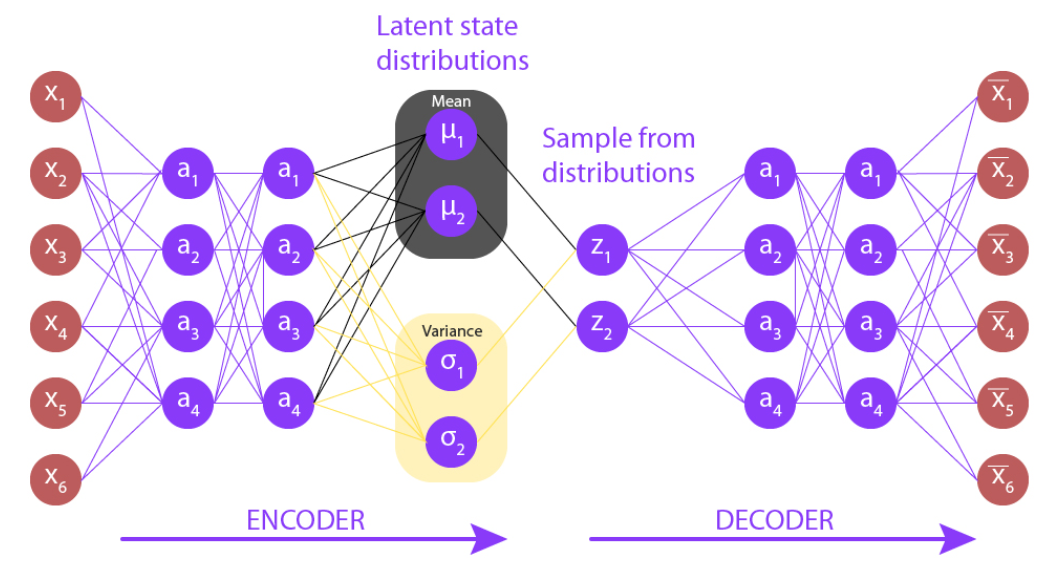

In [16]:
# ACTUAL MODEL(ENCODER + DECODER)
class DefectCVAE(nn.Module):
    def __init__(self, node_dim, mask_dim, edge_dim, u_dim, hidden_dim, latent_dim):
        super().__init__()
        self.node_dim   = node_dim
        self.mask_dim   = mask_dim
        
        self.encoder = EncoderPart(node_dim, edge_dim, u_dim, latent_dim)
        # self.encoder = CVAE_Encoder(node_dim, edge_dim, u_dim, hidden_dim, latent_dim)
        self.decoder = DecoderPart(latent_dim, mask_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, data):
        mu, log_var = self.encoder(data)
        
        if self.training:
            z = self.reparameterize(mu, log_var)
        else:
            z = mu
            
        out_sites = data.x.shape[0]
        num, sites, species = self.decoder(z, data.u, out_sites, data.pristine_mask, data.pristine_edges, data.pristine_features)
        
        return num, sites, species, mu, log_var

# Test with first batch from loader
# for batch in full_train_loader:
for batch in high_train_loader:
    the_sample = batch

    MAX = the_sample.x.shape[0]

    # Test full model
    test_model = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    n, st, sp, mu, log_var = test_model(the_sample)
    break

### Loss Function

In [17]:
def cvae_loss(num, sites, species, target_structure_tensor, ref_mask, mu, log_var, beta, device, y):

    # gen_structure_tensor    = gen_structure_tensor.to(device)
    target_structure_tensor = target_structure_tensor.to(device)
    mu                      = mu.to(device)
    log_var                 = log_var.to(device)
    n_sites                 = target_structure_tensor.shape[0]
    y                       = y.to(device)

    # Predictions
    site_logits    = sites.to(device) # gen_structure_tensor[..., 0]
    species_logits = species.to(device) # gen_structure_tensor[..., 1:]
    pred_num_defects = 2.0 + 25.0 * torch.sigmoid(num.to(device))# .item()
    # pred_num_defects = torch.round(torch.sigmoid(site_logits)).sum()
    # pred_num_onehot = [1 if pred_num_defects == count else 0 for count in possible_num_defects]
    # pred_num_onehot = torch.tensor(pred_num_onehot, dtype=float)

    # Targets
    
    site_targets = y[:, :1].squeeze(-1).to(dtype=torch.float)
    species_targets = torch.argmax(y[:, 1:], dim=1)
    species_targets = (ref_mask == species_targets[:, None]).int().argmax(dim=1)

    # convert specie target into 0--> Normal, 1--> vacancy, and 2-->Substitution
    # orig_Z = (target_structure_tensor[..., 10] * 94).round().long().clamp(0, 118)
    # new_Z  = (target_structure_tensor[..., 3] * 94).round().long().clamp(0, 118)

    # site_targets    = (new_Z != orig_Z).float()
    # species_targets = new_Z.clamp(min=0).long()
    target_num_defects = site_targets.sum()
    # target_num_onehot = [1 if target_num_defects == count else 0 for count in possible_num_defects]
    # target_num_onehot = torch.tensor(target_num_onehot, dtype=float)

    # =====================
    # Defects Count Loss
    # =====================
    loss_num_defects = nn.MSELoss()

    pred_count = pred_num_defects
    target_count = target_num_defects

    defects_num_loss = loss_num_defects(pred_count, target_count)

    # =====================
    # Site Loss
    # =====================
    
    site_penalty    = (n_sites/target_num_defects.float()).clamp(max=50)
    site_weights    = torch.tensor([site_penalty], dtype=torch.float, device=device)
    
    loss_site   = nn.BCEWithLogitsLoss(pos_weight=site_weights)
    site_loss   = loss_site(site_logits, site_targets.unsqueeze(1))
    # site_loss    = F.binary_cross_entropy_with_logits(site_logits, site_targets, pos_weight=site_weights)
    
    # ======================
    # Species Loss
    # ======================

    defect_mask = site_targets.bool()
    # species_weights = torch.tensor(ref_mask, dtype=torch.float, device=device) * float(specie_penalty)
    loss_specie = nn.CrossEntropyLoss(weight=None) # species_weights)
    # species_loss = F.cross_entropy(species_logits, species_targets, weight=species_weights.expand(119))
    species_loss = loss_specie(species_logits, species_targets)

    # ======================
    # KL Loss
    # ======================

    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    # ======================
    # Total Loss
    # ======================

    total = defects_num_loss + site_loss + species_loss + (beta * kl_loss)
    
    return total, defects_num_loss, site_loss, species_loss, kl_loss

# Test loss function
# for a_batch in full_train_loader:
the_device = "cpu" # torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for a_batch in high_train_loader:
    test_model = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    n, st, sp, mu, log_var = test_model(a_batch)
    
    a,e,b,c,d = cvae_loss(n,st,sp, a_batch.x, a_batch.pristine_mask, mu, log_var, 1e-3, the_device, a_batch.y)
    print(f"total: {a}, defects_count_loss: {e}, site_loss: {b}, species_loss: {c}, kl_loss: {d}")

    break

total: 22.35875701904297, defects_count_loss: 19.73067283630371, site_loss: 1.3152883052825928, species_loss: 1.3127915859222412, kl_loss: 0.004025661386549473


/home/amutua/inverse/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


## Training and Testing

In [18]:
# Training Function
def train_model(model, train_loader, cvae_loss, current_beta, device, optimizer):
    # Set the model in training mode
    model.train()

    # To track the losses
    t_loss, c_loss, s_loss, sp_loss, kl_loss = 0.0, 0.0, 0.0, 0.0, 0.0
    s_accuracy, sp_accuracy = 0.0, 0.0

    for batch in tqdm(train_loader, leave=False):
        optimizer.zero_grad()

        # Output of the model
        batch = batch.to(device)
        nums, sts, sps, mu, log_var = model(batch)
        
        # NUM_SITES = batch.x.shape[0]
        # gen_structure_tensor = recon.view((NUM_SITES, (1 + MASK_DIM)))

        # The loss (pass batch.mask and configured weight_penalty)
        t,c,s,sp,kl = cvae_loss(nums, sts, sps, batch.x, batch.mask, mu, log_var, current_beta, device, batch.y)
        if torch.isnan(t).any():
            print("Found an NaN value")
            break
        
        t.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        t_loss  += t.item() * batch.num_graphs
        c_loss  += c.item() * batch.num_graphs
        s_loss  += s.item() * batch.num_graphs
        sp_loss += sp.item() * batch.num_graphs
        kl_loss += kl.item() * batch.num_graphs
        

    n = len(train_loader)
    t_losses = {"Total_loss": t_loss/n, "Defect_Count_loss": c_loss/n, "Site_loss": s_loss/n, "Species_loss": sp_loss/n, "KL_loss": kl_loss/n}

    return t_losses

def validate_model(model, val_loader, cvae_loss, current_beta, device):
    # Model in evaluation mode
    model.eval()
    
    t_loss, c_loss, s_loss, sp_loss, kl_loss = 0.0, 0.0, 0.0, 0.0, 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, leave=False):
            batch = batch.to(device)
            nums, sts, sps, mu, log_var = model(batch)
            # NUM_SITES = batch.x.shape[0]
            # recon = recon.view((NUM_SITES,(1 + MASK_DIM)))

            t,c,s,sp,kl = cvae_loss(nums, sts, sps, batch.x, batch.mask, mu, log_var, current_beta, device, batch.y)
            if torch.isnan(t).any():
                print("Found an NaN value")
                break

            t_loss += t.item() * batch.num_graphs
            c_loss += c.item() * batch.num_graphs
            s_loss += s.item() * batch.num_graphs
            sp_loss += sp.item() * batch.num_graphs
            kl_loss += kl.item() * batch.num_graphs

        n = len(val_loader)# .dataset)
        v_losses = {"Total_loss": t_loss/n, "Defect_Count_loss": c_loss/n, "Site_loss": s_loss/n, "Species_loss": sp_loss/n, "KL_loss": kl_loss/n}
        return v_losses

In [19]:
# Loaders for Full Dataset
# train_loader = full_train_loader 
# val_loader = full_val_loader 

# Loaders for Sample Dataset
train_loader = high_train_loader 
val_loader = high_val_loader 

# Parameters for training model
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

EPOCHS = 10
beta   = 1e-3

train_metrics, val_metrics = [], []


for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch:4d}")
    # Train
    current_beta = beta * min(1.0, epoch / EPOCHS)
    t_losses = train_model(model,train_loader, cvae_loss, current_beta, device, optimizer)

    # Validate
    val_losses = validate_model(model, val_loader, cvae_loss, current_beta, device)
    scheduler.step()

    # Store and print metrics
    train_metrics.append(t_losses)
    val_metrics.append(val_losses)
    
    print(f"Train      : {t_losses['Total_loss']:.4f} | {t_losses['Defect_Count_loss']:.4f} | {t_losses['Site_loss']:.4f} | {t_losses['Species_loss']:.4f} | {t_losses['KL_loss']:.4f}")
    print(f"Validation : {val_losses['Total_loss']:.4f} | {val_losses['Defect_Count_loss']:.4f} | {val_losses['Site_loss']:.4f} | {val_losses['Species_loss']:.4f} | {val_losses['KL_loss']:.4f}\n")

Epoch    1


Train      : 28254647431.8104 | 18.7359 | 1.3352 | 7.1409 | 282546481333917.5625
Validation : 11.0530 | 9.5653 | 1.3345 | 0.1529 | 3.5861

Epoch    2


Train      : 8.4557 | 6.9691 | 1.3345 | 0.1513 | 3.6491
Validation : 4.6976 | 3.2096 | 1.3345 | 0.1528 | 3.8492

Epoch    3


Train      : 5.7603 | 4.2739 | 1.3345 | 0.1508 | 3.7869
Validation : 5.2842 | 3.7967 | 1.3345 | 0.1519 | 3.5933

Epoch    4


Train      : 5.5209 | 4.0345 | 1.3345 | 0.1505 | 3.6143
Validation : 6.9702 | 5.4825 | 1.3344 | 0.1519 | 3.2477

Epoch    5


...

Train      : 4.5340 | 3.0476 | 1.3344 | 0.1502 | 3.0399
Validation : 4.3661 | 2.8771 | 1.3345 | 0.1527 | 3.0771

Epoch    7


Train      : 4.1677 | 2.6810 | 1.3344 | 0.1502 | 2.9576
Validation : 4.2856 | 2.7976 | 1.3344 | 0.1516 | 2.7541

Epoch    8


Train      : 3.9985 | 2.5117 | 1.3344 | 0.1501 | 2.8737
Validation : 4.6445 | 3.1560 | 1.3345 | 0.1517 | 2.9498

Epoch    9


Train      : 3.8460 | 2.3589 | 1.3344 | 0.1501 | 2.8485
Validation : 3.6157 | 2.1254 | 1.3345 | 0.1531 | 2.9541

Epoch   10


Train      : 3.6390 | 2.1518 | 1.3344 | 0.1500 | 2.7481
Validation : 2.7216 | 1.2329 | 1.3345 | 0.1516 | 2.6944



In [20]:
totals = [train_metrics[i]["Total_loss"] for i in range(len(train_metrics))]
counts = [train_metrics[i]["Defect_Count_loss"] for i in range(len(train_metrics))]
ss     = [train_metrics[i]["Site_loss"] for i in range(len(train_metrics))]
sps    = [train_metrics[i]["Species_loss"] for i in range(len(train_metrics))]
kls    = [train_metrics[i]["KL_loss"] for i in range(len(train_metrics))]

totals_v = [val_metrics[i]["Total_loss"] for i in range(len(val_metrics))]
counts_v = [val_metrics[i]["Defect_Count_loss"] for i in range(len(val_metrics))]
ss_v     = [val_metrics[i]["Site_loss"] for i in range(len(val_metrics))]
sps_v    = [val_metrics[i]["Species_loss"] for i in range(len(val_metrics))]
kls_v    = [val_metrics[i]["KL_loss"] for i in range(len(val_metrics))]

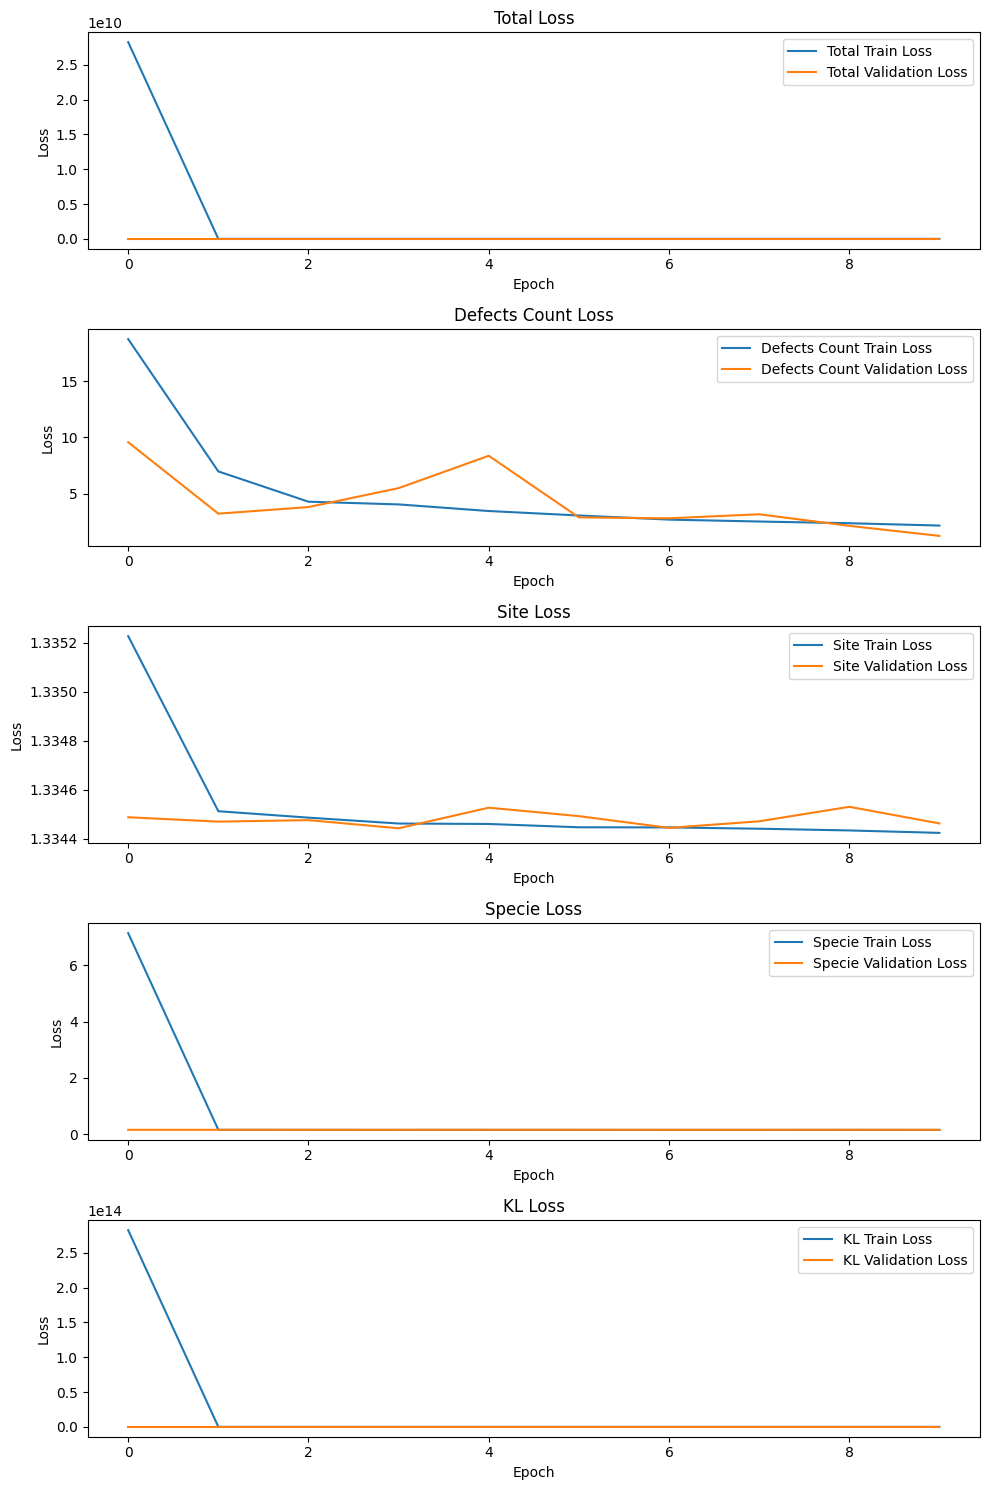

In [21]:
# Plot metrics
fig, axs = plt.subplots(5, 1, figsize=(10, 15))

axs[0].plot(totals, label='Total Train Loss')
axs[0].plot(totals_v, label='Total Validation Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Total Loss')
axs[0].legend()

axs[1].plot(counts, label='Defects Count Train Loss')
axs[1].plot(counts_v, label='Defects Count Validation Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Defects Count Loss')
axs[1].legend()

axs[2].plot(ss, label='Site Train Loss')
axs[2].plot(ss_v, label='Site Validation Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].set_title('Site Loss')
axs[2].legend()

axs[3].plot(sps, label='Specie Train Loss')
axs[3].plot(sps_v, label='Specie Validation Loss')
axs[3].set_xlabel('Epoch')
axs[3].set_ylabel('Loss')
axs[3].set_title('Specie Loss')
axs[3].legend()

axs[4].plot(kls, label='KL Train Loss')
axs[4].plot(kls_v, label='KL Validation Loss')
axs[4].set_xlabel('Epoch')
axs[4].set_ylabel('Loss')
axs[4].set_title('KL Loss')
axs[4].legend()

plt.tight_layout()
plt.show()

## Inverse Design

In [22]:
import gnn_models
import graphy_gnn

# Load Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# the_model = gnn_models.GNNModel1().to(device)
the_model = gnn_models.AI4matPart(26, 14, 6, embed_dim=32, num_blocks=3).to(device)
model_path = "Final_Dataset/gnn models/megnet_model.pth"
the_model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

In [ ]:

# Make Prediction
def add_bond_batch(graph):
    for data in graph:
        bond_batch = torch.zeros((1, data.edge_index.shape[1]))
        data.bond_batch = bond_batch.squeeze(0).to(dtype=torch.long)

    return graph 

def modify_x_global(graph):
    for data in graph:
        new_x = data.x[...,1:]

        all_u = data.u.squeeze(0)
        keep_indices = torch.tensor([0,1,8,11,12,13])
        new_u = torch.index_select(all_u, dim=0, index=keep_indices)
        
        data.x = new_x
        data.u = new_u.unsqueeze(0)
    return graph

def predict_bgv(the_model, device, original_structure, generated_structure, tbgv):

    # Prepare Generated Structure
    defective_structure = get_clean_defective(generated_structure)

    defects_structure = graphy_gnn.get_defects_structure(defective_structure, original_structure)

    nodes = graphy_gnn.get_nodes(defects_structure)
    edges, edge_features = graphy_gnn.get_edges_and_features(original_structure, defects_structure)
    global_features = graphy_gnn.get_globals(original_structure, defective_structure, defects_structure)
    target = tbgv
    # p_edges = get_pristine_edges(original_structure)

    the_data = Data(
        x=torch.tensor(nodes, dtype=torch.float),
        edge_index=torch.tensor(edges, dtype=torch.long),
        edge_attr=torch.tensor(edge_features, dtype=torch.float),
        u=torch.tensor(global_features, dtype=torch.float).unsqueeze(0),
        y=torch.tensor(target, dtype=torch.float).unsqueeze(0),
        # pristine_edges=torch.tensor(p_edges, dtype=torch.long)
    )

    the_data = modify_x_global(add_bond_batch([the_data]))

    attempt = DataLoader(the_data, batch_size=1, shuffle=False)

    # Make prediction
    the_prediction, the_target = gnn_models.predict(the_model, attempt, device)
    print(f"Predicted Band Gap: {the_prediction[0]}")
    # print(f"Target Band Gap: {the_target[0]}")
    
def gen_tensor(model, reference_structure, target_band_gap, device = "cpu"):
    model.eval()
    model.to(device)

    with torch.no_grad():
        # the_lattice = reference_structure.lattice
        ref_material = reference_structure.reduced_formula
        out_sites = len(reference_structure)
    
        condition = get_globals(ref_material, target_band_gap)
        
        the_z = torch.randn(1, 32, device=device)
        the_condition = torch.tensor(condition*1, dtype=torch.float).unsqueeze(0).to(device=device)
        the_mask = torch.tensor(get_mask(reference_structure), dtype=torch.bool)
        the_pristine_edges = torch.tensor(get_pristine_edges(reference_structure), dtype=torch.long)
        the_pristine_features = torch.tensor(get_site_features(reference_structure), dtype=torch.float)
        
        # Generated Edge Indices
        '''nodes = [i for i in range(out_sites)]
        nodes = [nodes for _ in range(out_sites)]
        adj = torch.tensor(nodes, dtype=torch.float)
        the_edge_index, edge_attr = dense_to_sparse(adj)'''
    
        # Run decoder
        defective_tensors = model.decoder(the_z, the_condition, out_sites, the_mask, the_pristine_edges, the_pristine_features)
        # defective_tensors = defective_tensors.view((out_sites, (1 + self.mask_dim)))

    return defective_tensors


def gen_structure(ref_structure, gen_tensor):
    all_sites = []
    ref_coords = ref_structure.frac_coords
    ref_elements = [site.specie for site in ref_structure.sites]
    structure_lattice = ref_structure.lattice
    the_idx = 0
    
    for row in gen_tensor:
        row = row.detach().cpu()

        the_site = row[0]
        site_state = torch.round(torch.sigmoid(the_site))

        if site_state == 0: # Normal site
            the_site = PeriodicSite(
                species= ref_elements[the_idx],
                coords= ref_coords[the_idx],
                coords_are_cartesian= False,
                lattice= structure_lattice
                )
        else: 
            logit_masks = row[1:]    
    
            cls_idx = int(logit_masks.argmax().item()) # 0 = vacancy, 1..118 = element
        
            the_site = PeriodicSite(
                species= Element.from_Z(cls_idx).symbol if cls_idx > 0 else DummySpecie("X"),
                coords= ref_coords[the_idx],
                coords_are_cartesian= False,
                lattice= structure_lattice
                )

        all_sites.append(the_site)
        the_idx +=1

    result_structure = Structure.from_sites(all_sites)

    return result_structure

def get_clean_defective(full_defective_structure, save=False):
    all_elements = [Element.from_Z(z) for z in range(1, 119)]

    unwanted_sites_index = []

    idx = 0
    
    for site in full_defective_structure.sites:
        if site.specie not in all_elements:
            unwanted_sites_index.append(idx)
        idx += 1
    
    new_defective_structure = full_defective_structure.remove_sites(unwanted_sites_index)

    if save:
        writer = CifWriter(new_defective_structure)
        writer.write_file(f"Final_Dataset/cvae models/Generated_Structures/{new_defective_structure.formula}.cif")

    return new_defective_structure

def get_visualization(full_defective_structure, pristine_structure):
    
    cloud = get_cloud(full_defective_structure, pristine_structure)

    defective = get_clean_defective(full_defective_structure)

    # if vis:
    fig, num = plt.subplots(1,3, figsize=(15,5))
    # Visualize the pristine structure
    new_pristine = AseAtomsAdaptor.get_atoms(pristine_structure)
    plot_atoms(new_pristine, num[0])
    num[0].set_title("Structure without defects")

    # Visualize the defective structure
    new_defective = AseAtomsAdaptor.get_atoms(defective)
    plot_atoms(new_defective, num[1])
    num[1].set_title("Structure with defects")

    # Visualize the structure without defects
    new_cloud = AseAtomsAdaptor.get_atoms(cloud)
    plot_atoms(new_cloud, num[2])
    num[2].set_title("Defects only structure")

comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")

def test_from_df(the_material):

    sample_df = comb_df[comb_df["dataset_material"] == f"high_{the_material}"]
    
    choose_sample = random.randint(0,len(sample_df)-1)

    sample_row = sample_df.iloc[choose_sample]

    # Get required attributes from sample row
    sample_dataset_material = sample_row["dataset_material"]
    sample_id = sample_row["_id"]

    # Get defective structure
    clean_defective_path = f"original_dataset/{sample_dataset_material}/cifs/{sample_id}.cif"
    clean_defective_structure = Structure.from_file(clean_defective_path)

    # Get reference structure
    pristine_path = f"Final_Dataset/ref_cifs/{sample_dataset_material}.cif"
    pristine_structure = Structure.from_file(pristine_path)

    # Get Full Defective Structure
    full_defective_structure  = get_full_defective(pristine_structure, clean_defective_structure)

    sample_bgv = sample_row["band_gap_value"]
    print(f"Target Band Gap  : {sample_bgv}\n")

    print("TARGET STRUCTURE")
    print(f"Structure Formula: {full_defective_structure.formula}")

    sample_defects_count = sample_row["defect_sites"]
    print(f"Defects Count    : {sample_defects_count}\n")

    generated_tensor    = gen_tensor(model, pristine_structure, sample_bgv, "cpu")
    generated_structure = gen_structure(pristine_structure, generated_tensor)

    print("PREDICTED STRUCTURE")
    print(f"Structure Formula: {generated_structure.formula}")

    gen_cloud = get_cloud(generated_structure, pristine_structure)
    print(f"Defects Count    : {len(gen_cloud)}")


    return pristine_structure, full_defective_structure, generated_structure, sample_bgv

In [122]:
original_structure, target_structure, generated_structure, tbgv = test_from_df("InSe")

# the_cloud = get_cloud(generated_structure, original_structure)

print("\nThe Standard Structure")
get_visualization(target_structure, original_structure)

print("The Generated Structure")
get_visualization(generated_structure, original_structure)

print("\nBAND GAP OF GENERATED STRUCTURE")
predict_bgv(the_model, device, original_structure, generated_structure, tbgv)


Target Band Gap  : 0.3213500000000007

TARGET STRUCTURE
Structure Formula: X8 In66 Ga3 Se64 S3
Defects Count    : 14.0

PREDICTED STRUCTURE
Structure Formula: In72 Se72


/tmp/ipykernel_318281/3557309929.py:4: FutureWarning: with_local_env_strategy is deprecated, and will be removed on 2025-03-20
Use from_local_env_strategy in pymatgen.analysis.graphs instead.
Deprecated on 2024-03-29.
  the_graph = StructureGraph.with_local_env_strategy(structure, mdnn)


ValueError: You need at least 1 site to construct a Structure